## Random Forest Classifier
>1. Train Random Forest on TreeLSTM embeddings 
>2. Train on both Clinical Data concatenated with TreeLSTM embeddings
>3. Compare Feature Importance of both

In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

Test Accuracy: 0.4412, AUC: 0.4464
[[11 20]
 [18 19]]
              precision    recall  f1-score   support

           0       0.38      0.35      0.37        31
           1       0.49      0.51      0.50        37

    accuracy                           0.44        68
   macro avg       0.43      0.43      0.43        68
weighted avg       0.44      0.44      0.44        68



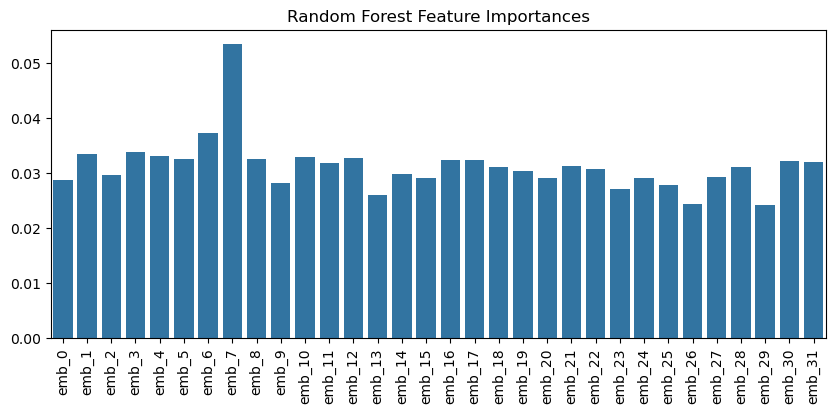

In [2]:
# Load embeddings + labels
emb = pd.read_csv("patient_embeddings_with_labels.csv")
tx = pd.read_csv("data/tracerX.csv")
tx.columns = tx.columns.str.strip()

tx_keep = tx[['cruk_id', 'dfs_time', 'cens_dfs']].copy()
df_features = emb.merge(tx_keep, on='cruk_id', how='inner')
df_features = df_features.dropna(subset=['dfs_time', 'cens_dfs'])
df_features = df_features[df_features['dfs_time'] > 0]

# Feature matrix and labels
X = df_features[[str(i) for i in range(32)]].values
y = df_features['shorter_dfs_balanced'].values 

# Train Random Forest Classifier
# binary event: 1=shorter_dfs_balanced, 0=censored

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit Random Forest
rf = RandomForestClassifier(n_estimators=500, max_depth=None, random_state=42)
rf.fit(X_train, y_train)

# Predict
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:,1]

# Metrics
acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)
print(f"Test Accuracy: {acc:.4f}, AUC: {auc:.4f}")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Feature importance
importances = rf.feature_importances_
plt.figure(figsize=(10,4))
sns.barplot(x=[f"emb_{i}" for i in range(32)], y=importances)
plt.xticks(rotation=90)
plt.title("Random Forest Feature Importances")
plt.show()

### Merging TreeLSTM with Clinical Data

In [82]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import shap
import matplotlib.pyplot as plt

# Load embeddings and clinical data
emb = pd.read_csv("patient_embeddings_with_labels.csv")  # TreeLSTM embeddings
cleaned_tx_by_nan = pd.read_csv("data/20221109_TRACERx421_all_patient_df_Converted.csv")
cleaned_tx_by_nan.columns = cleaned_tx_by_nan.columns.str.strip()

# Drop column 'Unnamed: 0' if it exists
if 'Unnamed: 0' in cleaned_tx_by_nan.columns:
    cleaned_tx_by_nan = cleaned_tx_by_nan.drop(columns=['Unnamed: 0'])
# Rename 'patient_id' to 'cruk_id' in cleaned_tx_by_nan
if 'patient_id' in cleaned_tx_by_nan.columns:
    cleaned_tx_by_nan = cleaned_tx_by_nan.rename(columns={'patient_id': 'cruk_id'})

print(f"Shape of TracerX Dataset: {cleaned_tx_by_nan.shape}")
print(f"Shape of TreeLSTM Dataset: {emb.shape}")

# Convert numeric IDs to CRUK format (zero-padded 4 digits)
cleaned_tx_by_nan['cruk_id'] = cleaned_tx_by_nan['cruk_id'].astype(str).str.zfill(4)
cleaned_tx_by_nan['cruk_id'] = "CRUK" + cleaned_tx_by_nan['cruk_id']

# Let's use the relevant clinical features from cleaned_tx_by_nan
tx_keep = cleaned_tx_by_nan.copy()

# Print first few rows of 'cruk_id' in both dataframes for debugging
print("First few 'cruk_id' values in TreeLSTM DataFrame:")
print(emb['cruk_id'].head())
print(emb.shape)
print("First few 'cruk_id' values in TracerX DataFrame:")
print(tx_keep['cruk_id'].head())
print(tx_keep.shape)

# Merge embeddings with clinical features
df_features = emb.merge(tx_keep, on='cruk_id', how='inner')
print(f"Columns in merged DataFrame (df_features): {len(df_features.columns)}")
print(f"Shape of merged DataFrame (df_features): {df_features.shape}")
print(f"Columns in df_features (merged on cruk_id): {emb.shape[1]} + {tx_keep.shape[1] - 1} = {df_features.shape[1]}")


Shape of TracerX Dataset: (421, 45)
Shape of TreeLSTM Dataset: (339, 34)
First few 'cruk_id' values in TreeLSTM DataFrame:
0    CRUK0005
1    CRUK0057
2    CRUK0039
3    CRUK0196
4    CRUK0023
Name: cruk_id, dtype: object
(339, 34)
First few 'cruk_id' values in TracerX DataFrame:
0    CRUK0032
1    CRUK0107
2    CRUK0109
3    CRUK0087
4    CRUK0043
Name: cruk_id, dtype: object
(421, 45)
Columns in merged DataFrame (df_features): 78
Shape of merged DataFrame (df_features): (201, 78)
Columns in df_features (merged on cruk_id): 34 + 44 = 78


SHAP values shape: (41, 36, 2)
X_test shape: (41, 36)
Fixed SHAP values shape: (41, 36)


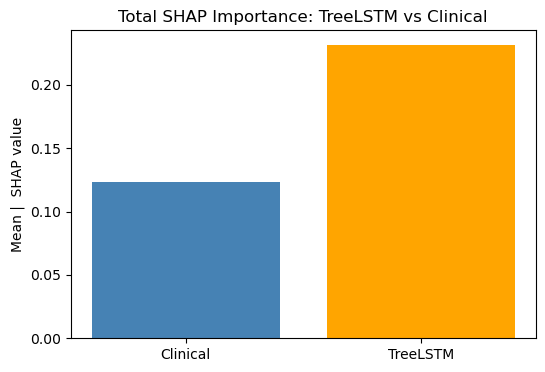

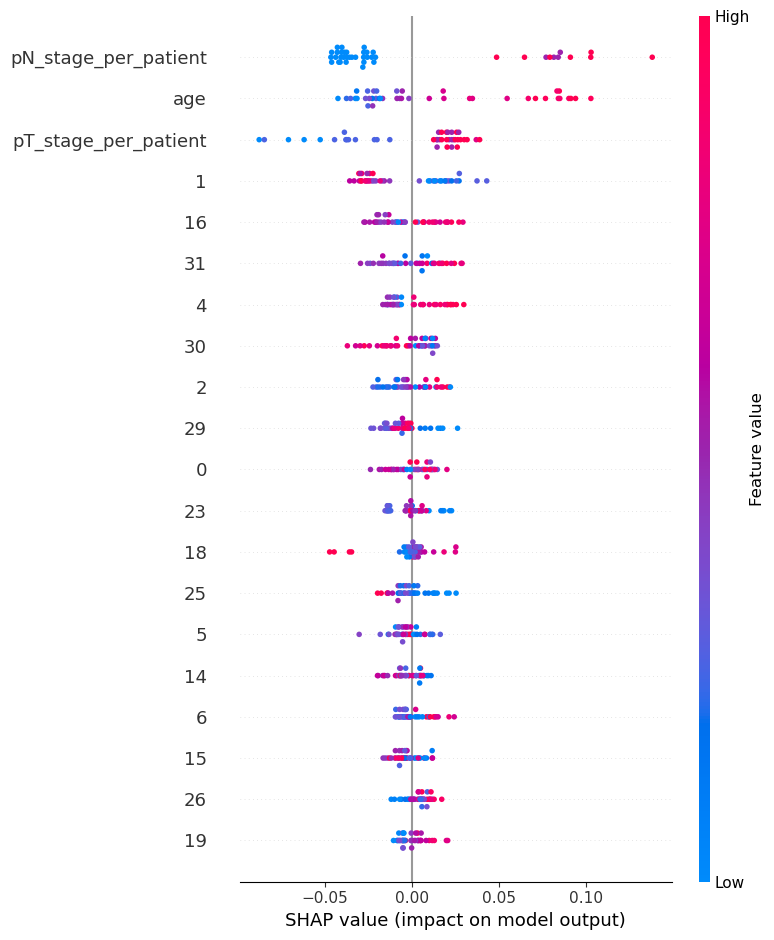

In [84]:
# Ensure 'dfs_time' and 'cens_dfs' exist before dropping NaN values
if 'dfs_time' not in df_features.columns or 'cens_dfs' not in df_features.columns:
    raise KeyError("'dfs_time' or 'cens_dfs' column is missing in the merged DataFrame (df_features). Please check the input files.")

df_features = df_features.dropna(subset=['dfs_time', 'cens_dfs'])

# Define feature groups
tree_cols = [str(i) for i in range(32)]     # TreeLSTM embedding columns
clinical_cols = ['age', 'pT_stage_per_patient', 'pN_stage_per_patient', 'sex']  # example clinical features

# Drop rows with NaN values in clinical columns after conversion
df_features = df_features.dropna(subset=clinical_cols)

X = df_features[tree_cols + clinical_cols]
y = df_features['cens_dfs']                 # Target variable for survival analysis: shorter DFS time VERY VERY INTERESTING!!!

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Random Forest
rf = RandomForestClassifier(n_estimators=500, random_state=42)
rf.fit(X_train, y_train)

# SHAP analysis
explainer = shap.TreeExplainer(rf)
shap_exp = explainer(X_test)  # Explanation object

# Access SHAP values
shap_values_all = shap_exp.values  # shape: (n_samples, n_features, n_classes)

print("SHAP values shape:", shap_values_all.shape)
print("X_test shape:", X_test.shape)

# Select class 1 (positive class)
shap_values = shap_values_all[:, :, 1]  # now (n_samples, n_features)
print("Fixed SHAP values shape:", shap_values.shape)

# Compute per-feature importance
importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance": np.abs(shap_values).mean(axis=0)
})
importance_df["group"] = importance_df["feature"].apply(
    lambda f: "TreeLSTM" if f in tree_cols else "Clinical"
)

# Plot group-level comparison
plt.figure(figsize=(6,4))
group_importance = importance_df.groupby("group")["importance"].sum().reset_index()
plt.bar(group_importance["group"], group_importance["importance"], color=["steelblue","orange"])
plt.title("Total SHAP Importance: TreeLSTM vs Clinical")
plt.ylabel("Mean |  SHAP value")
plt.show()

# Detailed per-feature summary
shap.summary_plot(shap_values, X_test, feature_names=X_test.columns)

Explaining patient at index 0, true label = 1
Patient 0, true label = 1


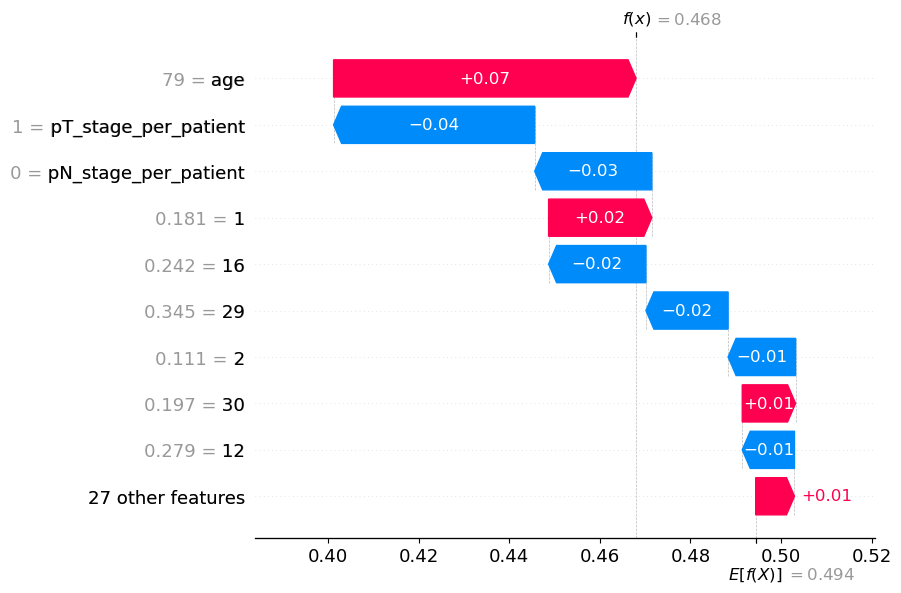

Patient 1, true label = 1


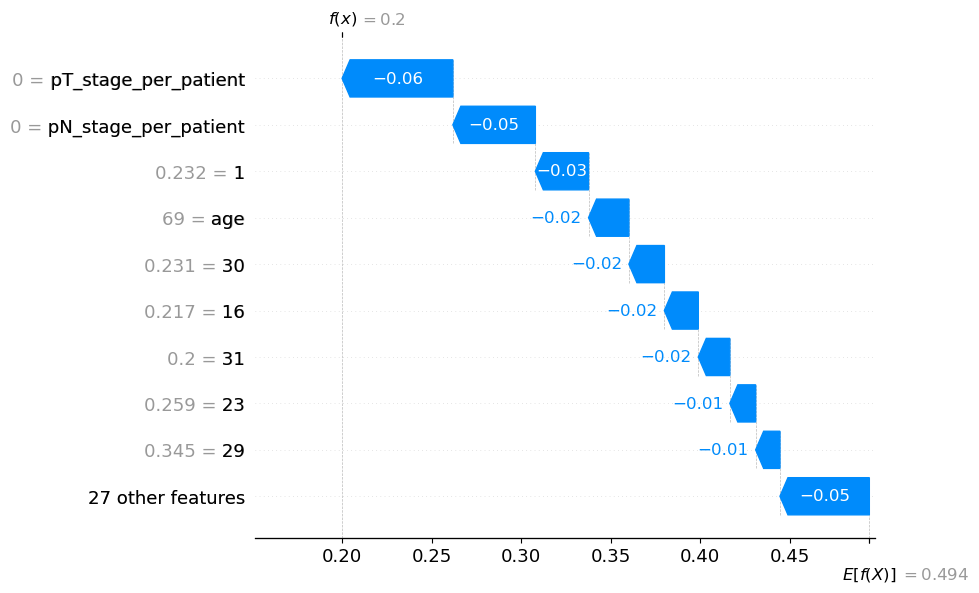

Patient 2, true label = 1


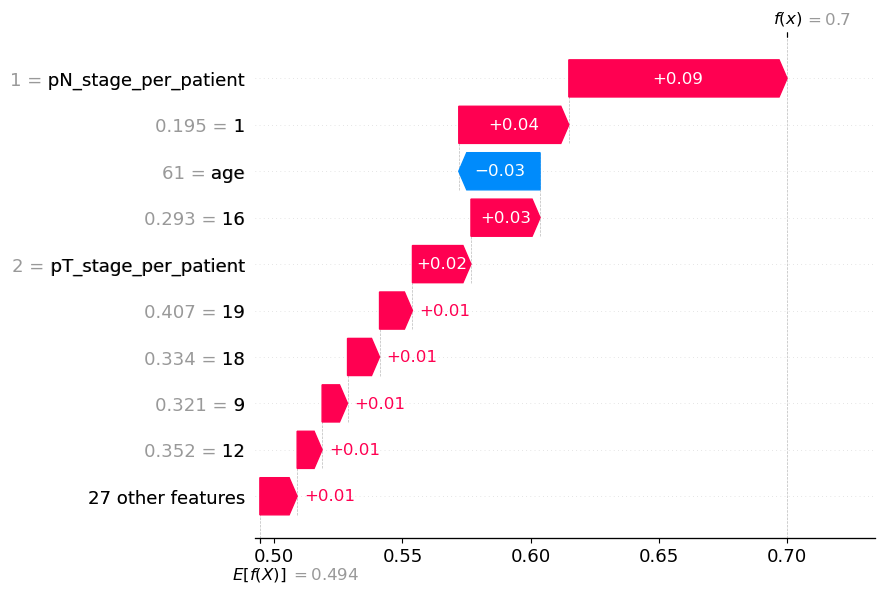

In [85]:
# Pick one example patient from the test set
i = 0  # index of the patient in X_test
sample = X_test.iloc[i]
# For binary classifiers, explainer.expected_value is a list of two base values
base_val = explainer.expected_value if isinstance(explainer.expected_value, float) else explainer.expected_value[1]  # baseline for class 1

print(f"Explaining patient at index {i}, true label = {y_test.iloc[i]}")


# Plot waterfall for first 3 patients
for idx in range(3):
    sample = X_test.iloc[idx]
    true_label = y_test.iloc[idx]

    # For binary classifiers, pick the base value for class 1
    base_val = explainer.expected_value if isinstance(explainer.expected_value, float) else explainer.expected_value[1]

    print(f"Patient {idx}, true label = {true_label}")

    shap_exp_patient = shap.Explanation(
        values=shap_values[idx],     # SHAP values for this patient (all features)
        base_values=base_val,       # baseline for class 1
        data=sample.values,
        feature_names=X_test.columns
    )

    # Use the modern waterfall plot
    shap.plots.waterfall(shap_exp_patient)


Using clinical features: ['age', 'sex', 'ethnicity', 'cigs_perday', 'years_smoking', 'packyears', 'smoking_status_merged', 'is.family.lung', 'ECOG_PS', 'pathologyTNM', 'pT_stage_per_patient', 'pN_stage_per_patient', 'LVI_per_patient', 'size_pathology_per_patient', 'Surgery_type', 'histology_lesion1', 'lesion1_sampled', 'histology_lesion2', 'lesion2_sampled', 'histology_multi_full', 'histology_multi_full_genomically.confirmed', 'LUAD_pred_subtype', 'adjuvant_treatment_YN', 'adjuvant_treatment_given', 'num_cycle_na.added', 'CHMPlatDgName_cleaned', 'CHMOthDgName_cleaned', 'AdjRadStartTime_manual', 'AdjRadEndTime_manual', 'Recurrence_time_use', 'newPrim_time_use', 'first_dfs_any_event_rec.or.new.primary', 'first_event_during_followup', 'cens_os', 'os_time', 'cens_dfs_any_event', 'dfs_time_any_event', 'cens_lung_event', 'lung_event_time', 'Relapse_cat', 'Relapse_cat_new', 'tx100']
SHAP values shape: (41, 74)


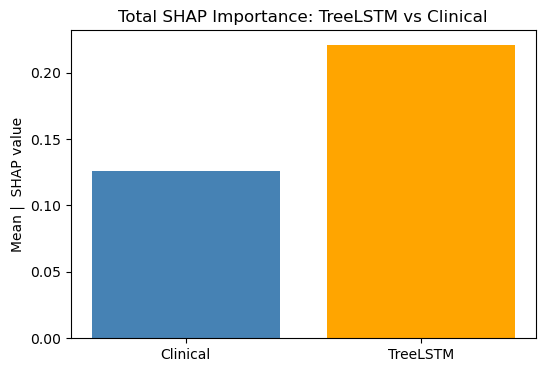

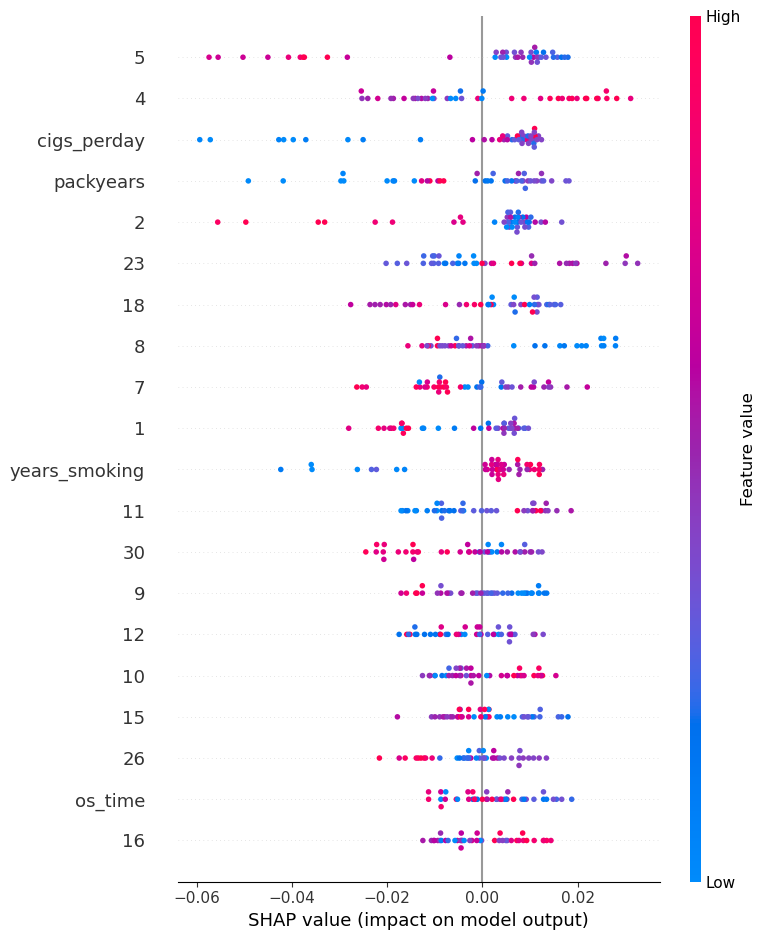

In [56]:
# Identify TreeLSTM columns (0 to 31)
tree_cols = [str(i) for i in range(32)]

# Automatically select all clinical columns
clinical_cols = [c for c in df_features.columns if c not in tree_cols + ['cruk_id', 'dfs_time', 'cens_dfs', 'shorter_dfs_balanced']]

print("Using clinical features:", clinical_cols)

# Prepare feature matrix
X = df_features[tree_cols + clinical_cols]
y = df_features['shorter_dfs_balanced'].values 

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Random Forest
rf = RandomForestClassifier(n_estimators=500, random_state=42)
rf.fit(X_train, y_train)

# SHAP analysis
explainer = shap.TreeExplainer(rf)
shap_exp = explainer(X_test)  # returns Explanation object

# Extract SHAP values
shap_values = shap_exp.values  # shape: (n_samples, n_features) or (n_samples, n_features, n_classes)

# Handle binary/multi-class
if shap_values.ndim == 3:  # multi-class
    # For binary classification, pick the positive class automatically
    if shap_values.shape[2] == 2:
        shap_values = shap_values[:, :, 1]  # positive class
    else:
        # For >2 classes, you could either pick a class or sum/average across classes
        shap_values = shap_values.mean(axis=2)  # average SHAP across classes


# Check shapes
print("SHAP values shape:", shap_values.shape)

# Per-feature importance
importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance": np.abs(shap_values).mean(axis=0)
})
importance_df["group"] = importance_df["feature"].apply(
    lambda f: "TreeLSTM" if f in tree_cols else "Clinical"
)

# Group-level plot
plt.figure(figsize=(6,4))
group_importance = importance_df.groupby("group")["importance"].sum().reset_index()
plt.bar(group_importance["group"], group_importance["importance"], color=["steelblue","orange"])
plt.title("Total SHAP Importance: TreeLSTM vs Clinical")
plt.ylabel("Mean |  SHAP value")
plt.show()

# Detailed per-feature SHAP summary
shap.summary_plot(shap_values, X_test, feature_names=X_test.columns)

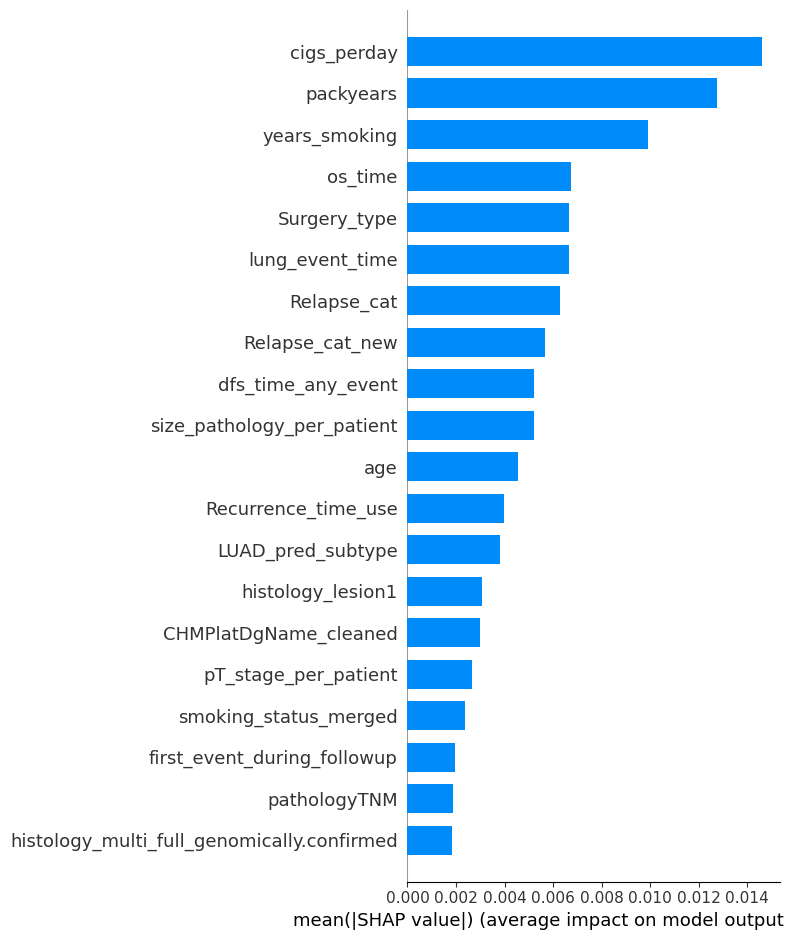

In [12]:
# Clinical features only
X_test_clinical = X_test[clinical_cols]
shap_values_clinical = shap_values[:, [X_test.columns.get_loc(f) for f in clinical_cols]]

# Summary plot for clinical features
shap.summary_plot(
    shap_values_clinical, 
    X_test_clinical, 
    feature_names=clinical_cols,
    plot_type="bar"
)

### Most Important Features


In [13]:
print("SHAP analysis completed successfully.")
# Print the top features by importance
top_features = importance_df.sort_values(by="importance", ascending=False).head(10)
print("Top features by SHAP importance:")
print(top_features)


SHAP analysis completed successfully.
Top features by SHAP importance:
        feature  importance     group
5             5    0.017789  TreeLSTM
4             4    0.015224  TreeLSTM
35  cigs_perday    0.014624  Clinical
37    packyears    0.012748  Clinical
2             2    0.011725  TreeLSTM
23           23    0.011505  TreeLSTM
18           18    0.011184  TreeLSTM
8             8    0.010804  TreeLSTM
7             7    0.010006  TreeLSTM
1             1    0.009989  TreeLSTM


Patient 0, true label = 0 (clinical features only)


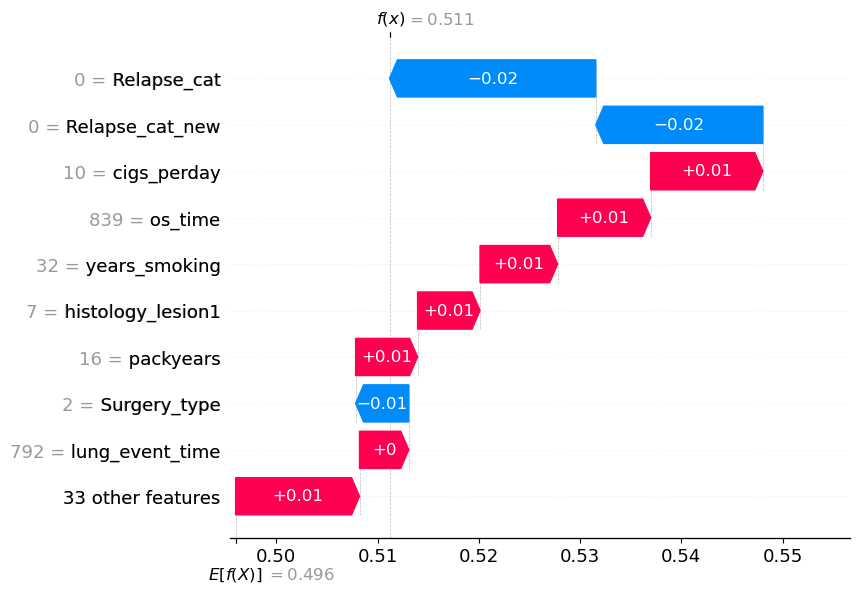

Patient 1, true label = 0 (clinical features only)


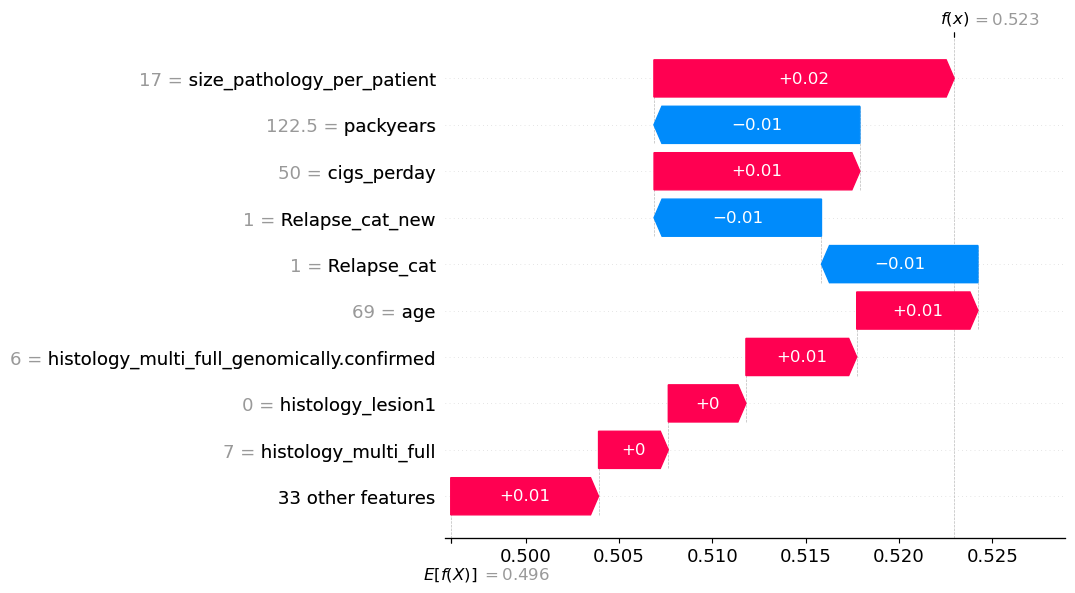

Patient 2, true label = 0 (clinical features only)


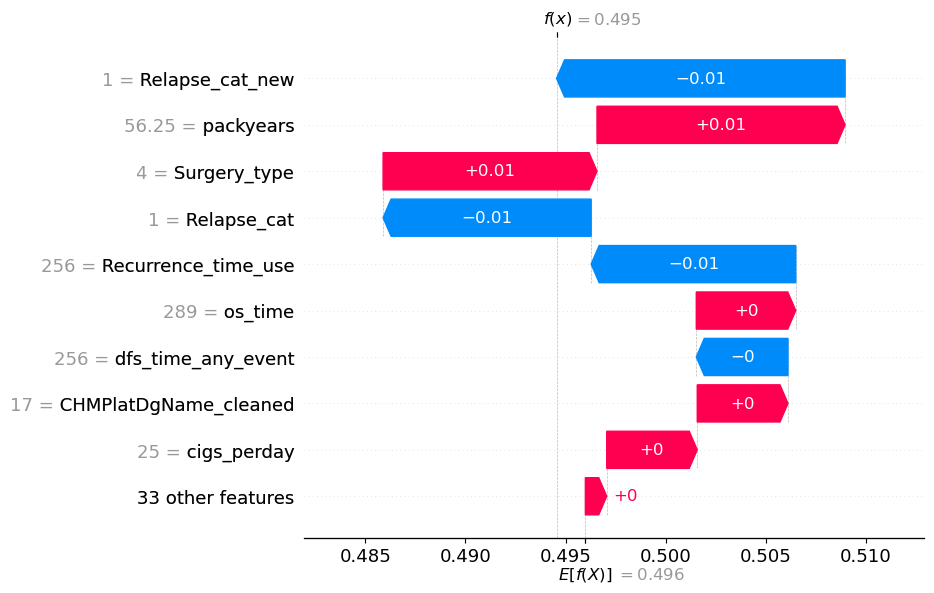

In [17]:
# Get all clinical columns automatically (exclude embedding columns)
clinical_cols = [c for c in X_test.columns if c not in tree_cols]

# Extract SHAP values for clinical features
clinical_indices = [X_test.columns.get_loc(f) for f in clinical_cols]

# Plot waterfall for first 3 patients
for idx in range(3):
    sample = X_test[clinical_cols].iloc[idx]
    true_label = y_test[idx]   # FIX: no .iloc if y_test is numpy

    # Extract SHAP values only for clinical features
    values_clinical = shap_values[idx][clinical_indices]

    # For binary classifier: pick base value for class 1
    base_val = explainer.expected_value if isinstance(explainer.expected_value, float) else explainer.expected_value[1]

    print(f"Patient {idx}, true label = {true_label} (clinical features only)")

    shap_exp_patient = shap.Explanation(
        values=values_clinical,
        base_values=base_val,
        data=sample.values,
        feature_names=clinical_cols
    )

    shap.plots.waterfall(shap_exp_patient)



Patient 0, true label = 0 (all features)


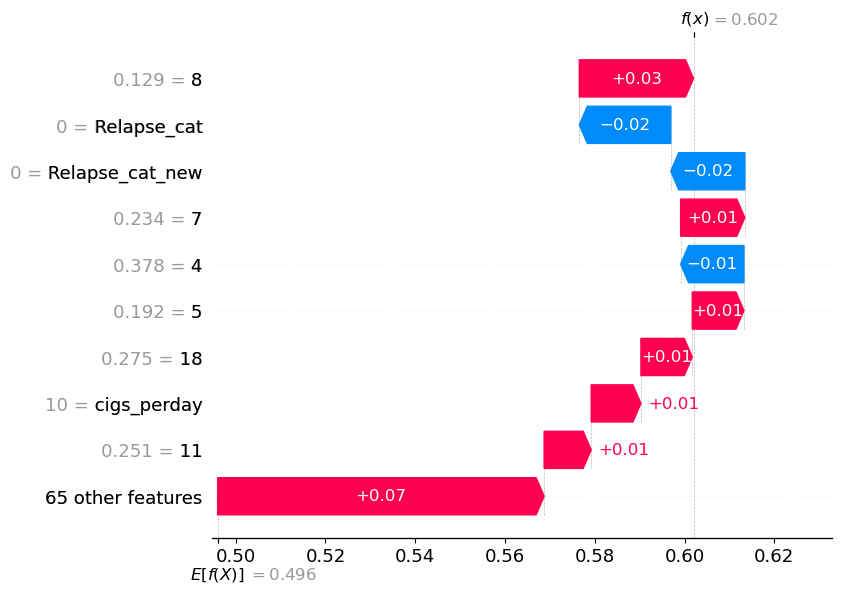

Patient 1, true label = 0 (all features)


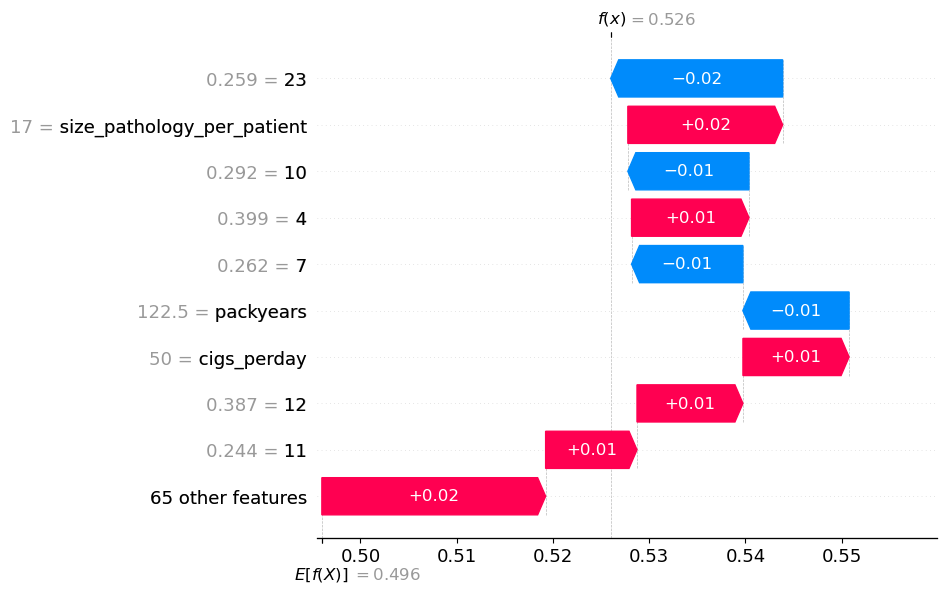

Patient 2, true label = 0 (all features)


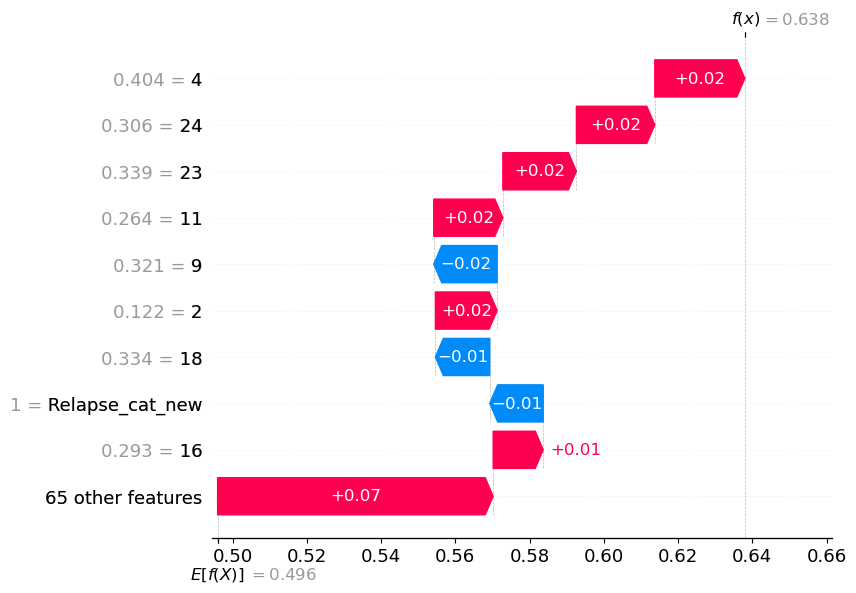

In [19]:
# Use all features
all_cols = X_test.columns
all_indices = range(len(all_cols))

# Plot waterfall for first 3 patients
for idx in range(3):
    sample = X_test.iloc[idx]  # full sample, not just clinical
    true_label = y_test[idx]   # works whether numpy or series

    # Extract SHAP values for all features
    values_all = shap_values[idx][all_indices]

    # For binary classifier: pick base value for class 1
    base_val = explainer.expected_value if isinstance(explainer.expected_value, float) else explainer.expected_value[1]

    print(f"Patient {idx}, true label = {true_label} (all features)")

    shap_exp_patient = shap.Explanation(
        values=values_all,
        base_values=base_val,
        data=sample.values,
        feature_names=all_cols
    )

    shap.plots.waterfall(shap_exp_patient)


Patient 0, true label = 0 (tree features only)


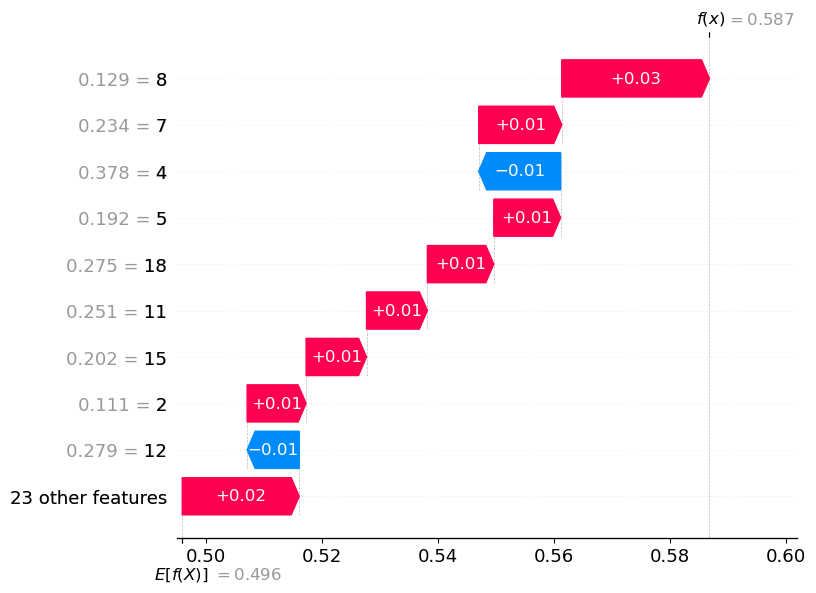

Patient 1, true label = 0 (tree features only)


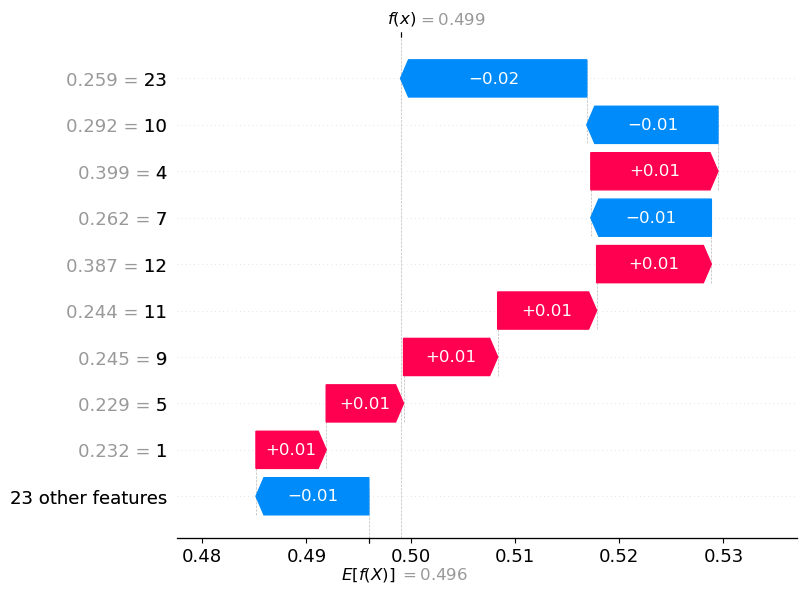

Patient 2, true label = 0 (tree features only)


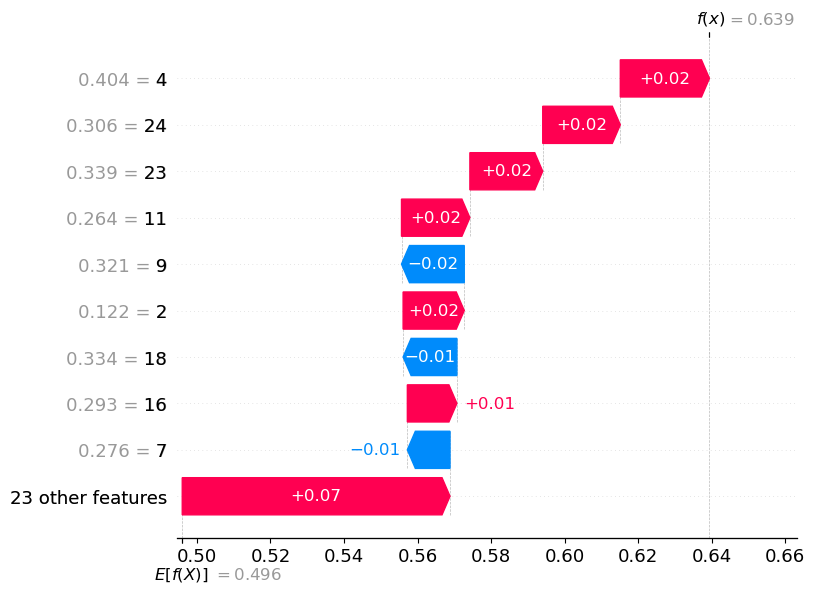

In [30]:
# Get only tree feature columns
tree_features = tree_cols  
tree_indices = [X_test.columns.get_loc(f) for f in tree_features]

# Plot waterfall for first 3 patients
for idx in range(3):
    sample = X_test[tree_features].iloc[idx]   # only tree features
    true_label = y_test[idx]                   # works if numpy or Series

    # Extract SHAP values for tree features
    values_tree = shap_values[idx][tree_indices]

    # For binary classifier: pick base value for class 1
    base_val = explainer.expected_value if isinstance(explainer.expected_value, float) else explainer.expected_value[1]

    print(f"Patient {idx}, true label = {true_label} (tree features only)")

    shap_exp_patient = shap.Explanation(
        values=values_tree,
        base_values=base_val,
        data=sample.values,
        feature_names=tree_features
    )

    shap.plots.waterfall(shap_exp_patient)

## Bayesian Probabilistic Classifier

In [44]:
import pymc as pm
import arviz as az
from sklearn.preprocessing import StandardScaler

X = df_features.drop(columns=["cruk_id", "cens_dfs", "dfs_time", "shorter_dfs_balanced"])  # keep only features
y = df_features['shorter_dfs_balanced'].values 

# Check for NaNs
nan_cols = X_test.columns[X_test.isna().any()].tolist()
print("Columns with NaN:", nan_cols)

# Fill NaNs with 0 or mean
X_clean = X_test.fillna(0)

# Use cleaned features (imputed or dropped NaNs)
X_bayes = X_clean.values  # shape (n_samples, n_features)
y_bayes = y_test  # shape (n_samples,)

# Standardize features
scaler = StandardScaler()
X_bayes_scaled = scaler.fit_transform(X_bayes)

n_samples, n_features = X_bayes_scaled.shape

with pm.Model() as bayes_logreg:
    # Priors
    intercept = pm.Normal("intercept", mu=0, sigma=0.5)
    beta = pm.Normal("beta", mu=0, sigma=0.5, shape=n_features)

    
    # Logistic regression
    logits = intercept + pm.math.dot(X_bayes_scaled, beta)
    p = pm.math.sigmoid(logits)
    
    # Likelihood
    y_obs = pm.Bernoulli("y_obs", p=p, observed=y_bayes)
    
    # Sample from posterior
    trace = pm.sample(
        2000,
        tune=1000,
        target_accept=0.995,
        random_seed=42,
        cores=4
    )

# Summarize posterior
az.summary(trace, var_names=["intercept", "beta"])

Initializing NUTS using jitter+adapt_diag...


Columns with NaN: ['AdjRadStartTime_manual', 'AdjRadEndTime_manual', 'Recurrence_time_use']


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, beta]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 6 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
intercept,-0.207,0.341,-0.861,0.416,0.003,0.004,14332.0,5998.0,1.0
beta[0],0.100,0.468,-0.764,1.003,0.004,0.006,14331.0,5877.0,1.0
beta[1],0.052,0.463,-0.796,0.954,0.004,0.006,14139.0,5898.0,1.0
beta[2],-0.175,0.476,-1.038,0.752,0.004,0.006,11440.0,5772.0,1.0
beta[3],-0.240,0.437,-1.020,0.628,0.004,0.005,12758.0,5971.0,1.0
...,...,...,...,...,...,...,...,...,...
beta[69],0.004,0.444,-0.788,0.883,0.004,0.005,11335.0,6374.0,1.0
beta[70],-0.230,0.458,-1.042,0.676,0.004,0.006,13252.0,6149.0,1.0
beta[71],0.155,0.446,-0.692,0.985,0.004,0.005,12991.0,6356.0,1.0
beta[72],0.145,0.425,-0.667,0.934,0.004,0.005,12400.0,6239.0,1.0


X_bayes_scaled shape: (41, 74)
beta_mean shape: (74,)


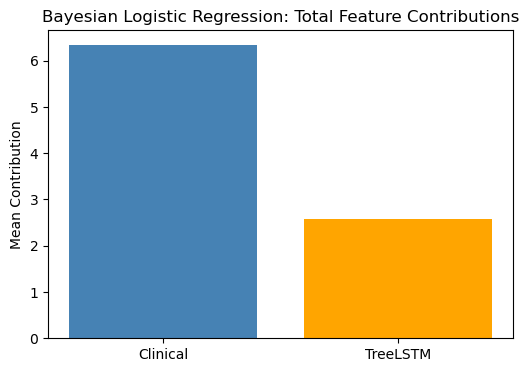

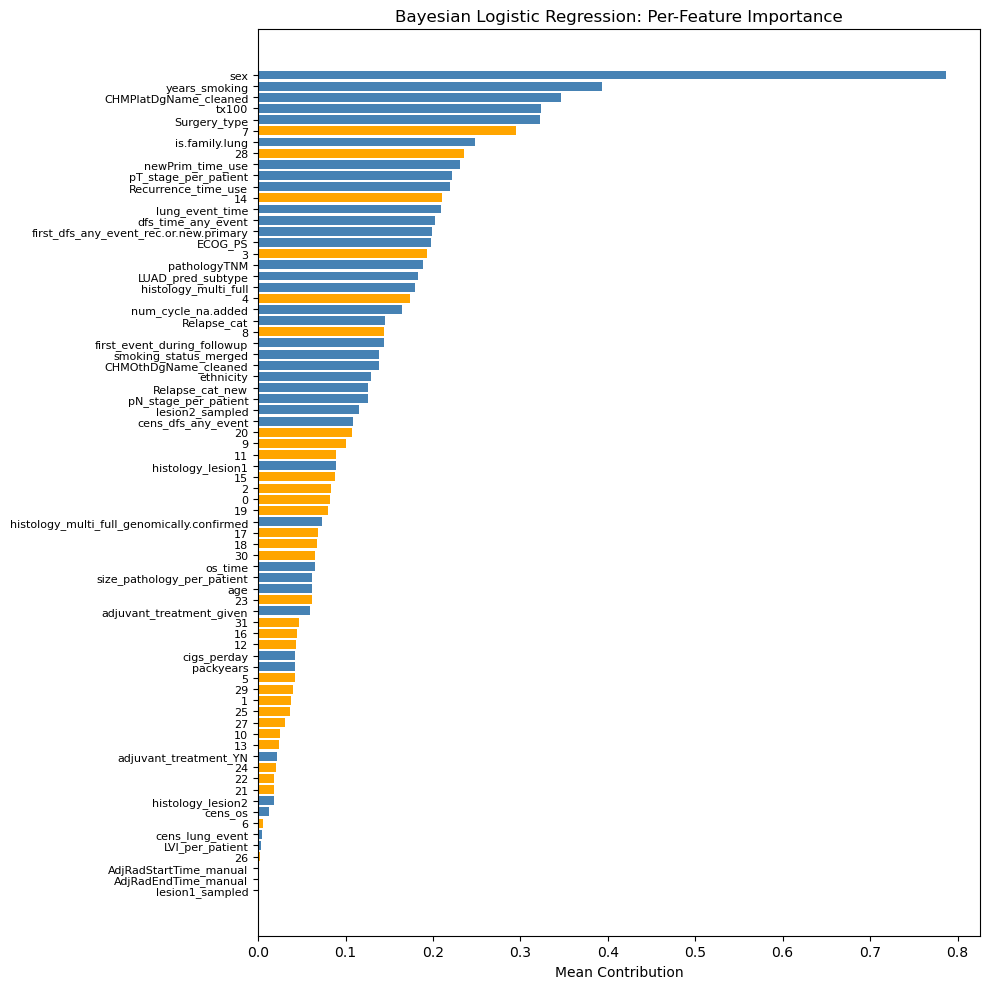

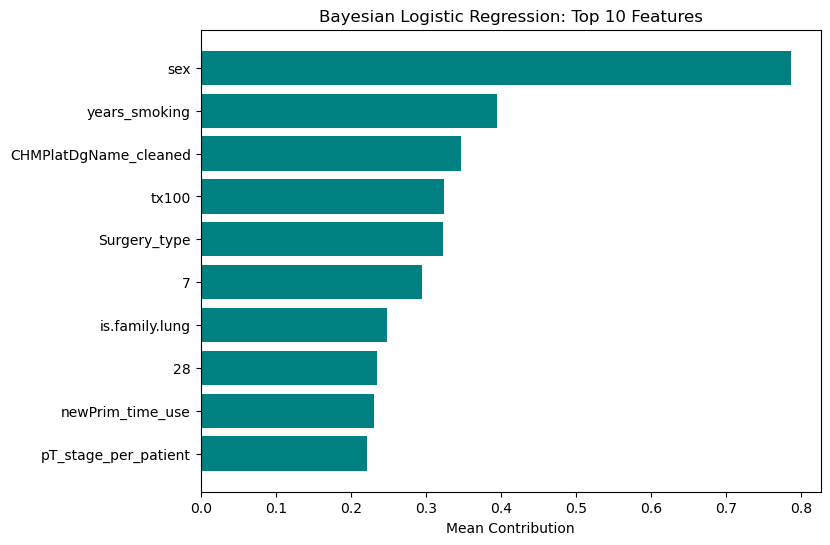

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract posterior means for coefficients
beta_samples = trace.posterior['beta'].stack(draws=("chain","draw")).values  # shape: (n_features, n_samples)
intercept_samples = trace.posterior['intercept'].stack(draws=("chain","draw")).values  # shape: (n_samples,)

# Compute posterior mean coefficients
beta_mean = beta_samples.mean(axis=1)
intercept_mean = intercept_samples.mean()

# Compute per-feature contribution for each sample
# contribution = feature_value * posterior_mean_coefficient
# Ensure the number of columns in X_bayes_scaled matches the number of columns in X
X_scaled_df = pd.DataFrame(X_bayes_scaled, columns=X.columns[:X_bayes_scaled.shape[1]])

print("X_bayes_scaled shape:", X_bayes_scaled.shape)  # should match n_features in model
print("beta_mean shape:", beta_mean.shape)


beta_mean_aligned = beta_mean[:X_scaled_df.shape[1]]  # first 10
feature_contrib = X_scaled_df * beta_mean_aligned

# Compute mean absolute contribution per feature
mean_abs_contrib = feature_contrib.abs().mean(axis=0)

importance_df = pd.DataFrame({
    "feature": X_scaled_df.columns,
    "importance": mean_abs_contrib
})

# Group by TreeLSTM vs Clinical
importance_df["group"] = importance_df["feature"].apply(
    lambda f: "TreeLSTM" if f in tree_cols else "Clinical"
)

# Plot group-level importance
group_importance = importance_df.groupby("group")["importance"].sum().reset_index()

plt.figure(figsize=(6,4))
plt.bar(group_importance["group"], group_importance["importance"], color=["steelblue","orange"])
plt.title("Bayesian Logistic Regression: Total Feature Contributions")
plt.ylabel("Mean Contribution")
plt.show()

# Detailed per-feature importance
importance_df_sorted = importance_df.sort_values("importance", ascending=False)
plt.figure(figsize=(10,10))
plt.barh(importance_df_sorted["feature"], importance_df_sorted["importance"], color="teal")
plt.xlabel("Mean Contribution")
plt.title("Bayesian Logistic Regression: Per-Feature Importance")
colors = ["steelblue" if g=="Clinical" else "orange" for g in importance_df_sorted["group"]]
plt.barh(importance_df_sorted["feature"], importance_df_sorted["importance"], color=colors)
plt.gca().invert_yaxis()
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()


# Detailed per-feature importance (top 10 only)
importance_df_sorted = importance_df.sort_values("importance", ascending=False).head(10)

plt.figure(figsize=(8,6))
plt.barh(importance_df_sorted["feature"], importance_df_sorted["importance"], color="teal")
plt.xlabel("Mean Contribution")
plt.title("Bayesian Logistic Regression: Top 10 Features")
plt.gca().invert_yaxis()
plt.show()


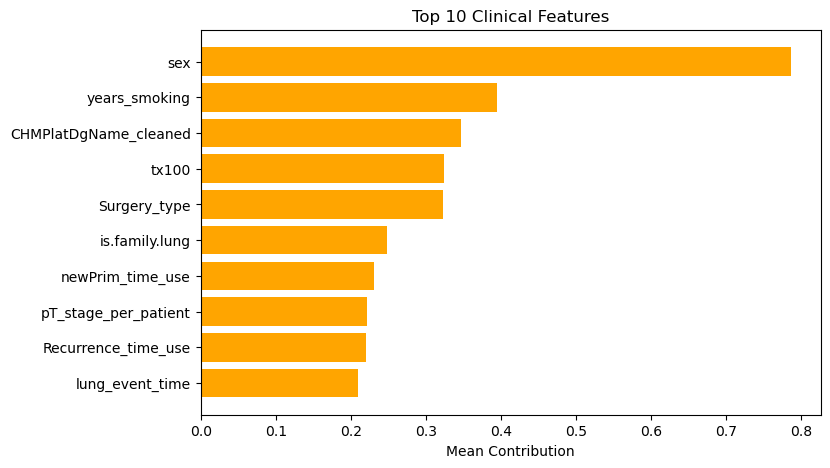

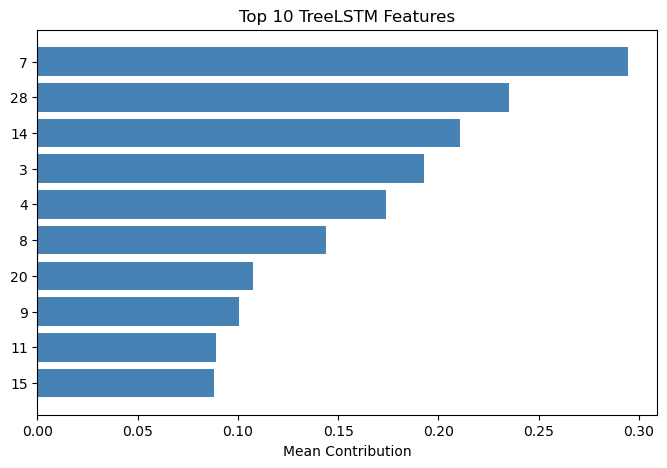

In [46]:
# Split importance by feature group so it is easier to read
importance_df["group"] = importance_df["feature"].apply(
    lambda f: "TreeLSTM" if f in tree_cols else "Clinical"
)

# Clinical features
importance_clinical = importance_df[importance_df["group"] == "Clinical"] \
    .sort_values("importance", ascending=False).head(10)

plt.figure(figsize=(8,5))
plt.barh(importance_clinical["feature"], importance_clinical["importance"], color="orange")
plt.xlabel("Mean Contribution")
plt.title("Top 10 Clinical Features")
plt.gca().invert_yaxis()
plt.show()

# TreeLSTM features
importance_tree = importance_df[importance_df["group"] == "TreeLSTM"] \
    .sort_values("importance", ascending=False).head(10)

plt.figure(figsize=(8,5))
plt.barh(importance_tree["feature"], importance_tree["importance"], color="steelblue")
plt.xlabel("Mean Contribution")
plt.title("Top 10 TreeLSTM Features")
plt.gca().invert_yaxis()
plt.show()

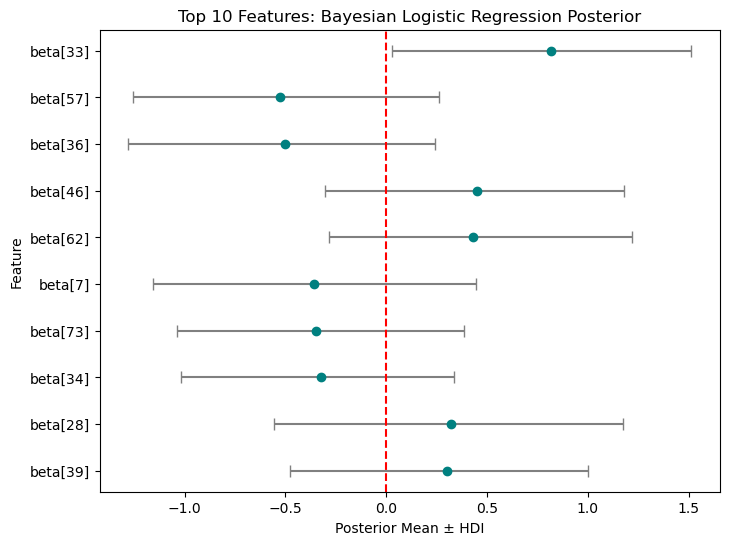

In [47]:
# Get the summary of the trace
summary_df = az.summary(trace, hdi_prob=0.94) # we are using 94% HDI

# Compute absolute mean for ranking
summary_df['abs_mean'] = summary_df['mean'].abs()

# Pick top 10 features
top_features = summary_df.sort_values('abs_mean', ascending=False).head(10)

# Create plot
plt.figure(figsize=(8,6))
plt.errorbar(
    x=top_features['mean'],
    y=top_features.index,
    xerr=[top_features['mean'] - top_features['hdi_3%'], 
          top_features['hdi_97%'] - top_features['mean']],
    fmt='o', color='teal', ecolor='gray', capsize=4
)
plt.axvline(0, color='red', linestyle='--')
plt.xlabel("Posterior Mean ± HDI")
plt.ylabel("Feature")
plt.title("Top 10 Features: Bayesian Logistic Regression Posterior")
plt.gca().invert_yaxis()  # largest mean on top
plt.show()

#### Plot Summary 
>- Each point represents the posterior mean of the coefficient.
>- The horizontal bar = 94% HDI (credible interval).
>- The red vertical line shows zero effect.
>- Features with bars not crossing zero are likely influential.
>- We can visually compare magnitude and uncertainty across features.

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, beta]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 10 seconds.
There were 8000 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [y_obs]


Output()

Shape of posterior predictive samples: (2050, 160)
                          Model    Metric      Mean  95%_CI_low  95%_CI_high
0  Bayesian Logistic Regression  Accuracy  0.502716    0.481250     0.531250
1  Bayesian Logistic Regression       AUC  0.499977    0.475621     0.525629
2  Bayesian Logistic Regression        F1  0.221937    0.024096     0.661088
3                 Random Forest  Accuracy  0.463415         NaN          NaN
4                 Random Forest       AUC  0.509569         NaN          NaN
5                 Random Forest        F1  0.421053         NaN          NaN


/var/folders/tc/wl6k8hsd2cl4l1d2_qncs5cm0000gn/T/ipykernel_10975/1240168829.py:112: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_comparison = pd.concat([bayes_metrics, rf_metrics], ignore_index=True)


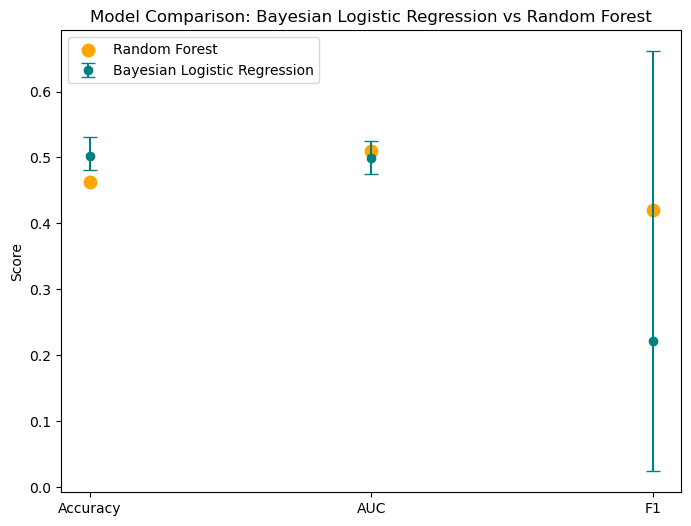

In [48]:
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
from sklearn.preprocessing import StandardScaler

# Bayesian Logistic Regression
# Select top 10 features for test to reduce dimensionality
top_features = importance_df.sort_values("importance", ascending=False)["feature"].iloc[:10].tolist()
X_top = df_features[top_features]  # Use only top 10 features
y = df_features['shorter_dfs_balanced'].values 

# Standardize features
X_scaled = StandardScaler().fit_transform(X)
n_features = X_scaled.shape[1]

# Fill NaNs with 0 or mean
X_clean = X_test.fillna(0)

# Use cleaned features (imputed or dropped NaNs)
X_bayes = X_clean.values  # shape (n_samples, n_features)
y_bayes = y_test  # shape (n_samples,)

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_bayes)

n_samples, n_features = X_scaled.shape

n_features = X_bayes.shape[1]

with pm.Model() as model:
    # Priors
    intercept = pm.Normal("intercept", mu=0, sigma=5)
    beta = pm.Normal("beta", mu=0, sigma=2, shape=n_features)
    
    # Logistic regression
    logits = intercept + pm.math.dot(X_bayes, beta)
    p = pm.math.sigmoid(logits)
    
    # Likelihood
    y_obs = pm.Bernoulli("y_obs", p=p, observed=y_bayes)
    
    # Sample from posterior
    trace = pm.sample(
        2000,
        tune=1000,
        target_accept=0.95,
        random_seed=42,
        cores=4
    )

X_bayes_scaled = scaler.fit_transform(X_train[top_features].fillna(0).values)
y_bayes = y_train

# Posterior predictive
with model:
    post_pred = pm.sample_posterior_predictive(trace, var_names=["y_obs"], random_seed=42, return_inferencedata=False)

y_pred_samples = post_pred["y_obs"].reshape(-1, y_bayes.shape[0])

print(f"Shape of posterior predictive samples: {y_pred_samples.shape}")
# y_pred_samples has shape (n_draws, n_train_samples)
accs, aucs, f1s = [], [], []

for y_sample in y_pred_samples:  # y_sample shape: (n_train_samples,)
    accs.append(accuracy_score(y_bayes, y_sample))
    aucs.append(roc_auc_score(y_bayes, y_sample))
    f1s.append(f1_score(y_bayes, y_sample))

accs = np.array(accs)
aucs = np.array(aucs)
f1s = np.array(f1s)

def summarize_metric(values):
    return {
        "mean": values.mean(),
        "hdi_3%": np.percentile(values, 3),
        "hdi_97%": np.percentile(values, 97)
    }

acc_summary = summarize_metric(accs)
auc_summary = summarize_metric(aucs)
f1_summary = summarize_metric(f1s)

bayes_metrics = pd.DataFrame({
    "Model": ["Bayesian Logistic Regression"]*3,
    "Metric": ["Accuracy", "AUC", "F1"],
    "Mean": [acc_summary["mean"], auc_summary["mean"], f1_summary["mean"]],
    "95%_CI_low": [acc_summary["hdi_3%"], auc_summary["hdi_3%"], f1_summary["hdi_3%"]],
    "95%_CI_high": [acc_summary["hdi_97%"], auc_summary["hdi_97%"], f1_summary["hdi_97%"]],
})

# Random Forest
rf = RandomForestClassifier(n_estimators=500, random_state=42)
rf.fit(X_train, y_train)
# Predicted labels on test set
y_pred_rf = rf.predict(X_test)
# Predicted probabilities (needed for AUC)
y_proba_rf = rf.predict_proba(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_proba_rf[:, 1])
f1_rf = f1_score(y_test, y_pred_rf)

rf_metrics = pd.DataFrame({
    "Model": ["Random Forest"]*3,
    "Metric": ["Accuracy", "AUC", "F1"],
    "Mean": [acc_rf, auc_rf, f1_rf],
    "95%_CI_low": [None, None, None],
    "95%_CI_high": [None, None, None]
})

# Display metrics for both models
metrics_comparison = pd.concat([bayes_metrics, rf_metrics], ignore_index=True)
print(metrics_comparison)
# Plotting comparison of Bayesian Logistic Regression vs Random Forest
plt.figure(figsize=(8,6))

# Plot Bayesian with error bars
bayes_subset = metrics_comparison[metrics_comparison["Model"]=="Bayesian Logistic Regression"]
plt.errorbar(
    bayes_subset["Metric"], bayes_subset["Mean"],
    yerr=[bayes_subset["Mean"]-bayes_subset["95%_CI_low"], 
          bayes_subset["95%_CI_high"]-bayes_subset["Mean"]],
    fmt="o", capsize=5, label="Bayesian Logistic Regression", color="teal"
)

# Plot Random Forest (point estimates)
rf_subset = metrics_comparison[metrics_comparison["Model"]=="Random Forest"]
plt.scatter(rf_subset["Metric"], rf_subset["Mean"], label="Random Forest", color="orange", s=80)

plt.ylabel("Score")
plt.title("Model Comparison: Bayesian Logistic Regression vs Random Forest")
plt.legend()
plt.show()


In [49]:
# Standardize the top 10 features in the test set
top_features = importance_df.sort_values("importance", ascending=False)["feature"].iloc[:10].tolist()

intercept_samples = trace.posterior["intercept"].stack(draws=("chain", "draw")).values  # (n_draws,)
beta_samples = trace.posterior["beta"].stack(draws=("chain", "draw")).values  # (n_features_total, n_draws)

# Select indices of top 10 features from the original training columns
X_bayes_df = pd.DataFrame(X_bayes, columns=df_features.columns[:X_bayes.shape[1]])
bayes_features = list(X_bayes_df.columns)
top_features_in_model = [f for f in top_features if f in bayes_features]
top_idx = [bayes_features.index(f) for f in top_features_in_model]

# Subset training and test sets to these features
X_train_top = X_train[top_features_in_model]
X_test_top = X_test[top_features_in_model]

# Refit scaler on training subset
scaler_top = StandardScaler().fit(X_train_top)

# Transform both train and test
X_train_scaled = scaler_top.transform(X_train_top)
X_test_scaled = scaler_top.transform(X_test_top)
X_test_scaled = np.nan_to_num(X_test_scaled, nan=0.0)

# Subset beta_samples
beta_top = beta_samples[top_idx, :].T

# Compute logits using only top 10 features
logits_test = intercept_samples[:, None] + np.dot(beta_top, X_test_scaled.T)
p_test = 1 / (1 + np.exp(-logits_test))
p_test = np.clip(p_test, 1e-6, 1-1e-6)
y_pred_test = np.random.binomial(1, p_test)

accs, aucs, f1s = [], [], []
for y_sample in y_pred_test:
    accs.append(accuracy_score(y_test, y_sample))
    aucs.append(roc_auc_score(y_test, y_sample))
    f1s.append(f1_score(y_test, y_sample))

accs = np.array(accs)
aucs = np.array(aucs)
f1s = np.array(f1s)

def summarize_metric(values):
    return {
        "mean": values.mean(),
        "hdi_3%": np.percentile(values, 3),
        "hdi_97%": np.percentile(values, 97)
    }

acc_summary = summarize_metric(accs)
auc_summary = summarize_metric(aucs)
f1_summary = summarize_metric(f1s)

bayes_metrics_test = pd.DataFrame({
    "Model": ["Bayesian Logistic Regression"]*3,
    "Metric": ["Accuracy", "AUC", "F1"],
    "Mean": [acc_summary["mean"], auc_summary["mean"], f1_summary["mean"]],
    "95%_CI_low": [acc_summary["hdi_3%"], auc_summary["hdi_3%"], f1_summary["hdi_3%"]],
    "95%_CI_high": [acc_summary["hdi_97%"], auc_summary["hdi_97%"], f1_summary["hdi_97%"]],
})

print(bayes_metrics_test)

                          Model    Metric      Mean  95%_CI_low  95%_CI_high
0  Bayesian Logistic Regression  Accuracy  0.497854    0.292683     0.707317
1  Bayesian Logistic Regression       AUC  0.495029    0.283493     0.705742
2  Bayesian Logistic Regression        F1  0.453600    0.210526     0.684211
